In [96]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score,accuracy_score, precision_score, recall_score, jaccard_score, hamming_loss
from scipy.spatial.distance import hamming, cosine
import random
import time
import csv
import json
import ast

#### Read datasets and compute evaluation metrics for all predictors (Level 1)

In [97]:
def return_df_to_evaluation(bias):
    def read(name):
        return pd.read_csv(f"valid_results/{name}_503.csv").drop(columns=["seconds"], errors="ignore")
    def safe_to_dict(x):
            if isinstance(x, dict):
                return x
            if pd.isna(x):
                return {}
            if isinstance(x, str):
                try:
                    return ast.literal_eval(x)
                except:
                    return {}
            return {}

    if bias=='baseline':
        baseline_1000 = pd.read_csv(f"valid_results/baseline_1000.csv")
        mr = baseline_1000[baseline_1000["Argument ID"].isin(args_id_503)].drop(columns=["seconds"], errors="ignore")

    else:
        mr = read(bias)
    all_in_list = mr['Argument ID'].isin(args_id_503).all()
    # print(f"All Argument IDs of {bias} are in the list of 503 arguments in the test set:", all_in_list)
    mr['dictionary_clean'] = mr['values'].apply(safe_to_dict)
    mr = mr.set_index("Argument ID")
    y_pred_mr = pd.json_normalize(mr['dictionary_clean'])
    y_pred_mr.index = mr.index
    return y_pred_mr

def compute_metrics(y_true, y_pred, name):
    
    metrics = {
        
        
        "macro_precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "micro_f1": f1_score(
            y_true, y_pred, average="micro", zero_division=0
        ),
        "hamming_loss": hamming_loss(y_true, y_pred),
    
        # "accuracy": accuracy_score(y_true, y_pred),
        # "global_kappa": cohen_kappa_score(
        #     np.asarray(y_true).ravel(),
        #     np.asarray(y_pred).ravel(),
        # ),
        "mean_jaccard": np.mean([
            jaccard_score(
                np.asarray(y_true)[i],
                np.asarray(y_pred)[i],
                zero_division=0,
            )
            for i in range(len(y_true))
        ]),
        "exact_match": np.mean([
            np.array_equal(
                np.asarray(y_true)[i],
                np.asarray(y_pred)[i],
            )
            for i in range(len(y_true))
        ]),
    }
    # print(f"Number of samples in .")
    print(f"\nMETRICS FOR {name} / y_true ({len(y_true)}) == y_pred ({len(y_pred)})\n-------------------------------------")
    for name, value in metrics.items():
        print(f"{name}: {value:.2f}")
    return metrics

In [ ]:
ground_truth = pd.read_csv("data/labels-level1_503.csv")
args_id_503 = ground_truth["Argument ID"].to_list()
y_true = ground_truth.set_index("Argument ID")

dataframes = ['motivated_reasoning',
                'confirmation_bias',
                'causal_oversimplification',
                'framing_effect',
                'hasty_generalization',
                'heuristics',
                'baseline'
                ]

for name in dataframes:
    y_pred = return_df_to_evaluation(name)
    common = y_true.index.intersection(y_pred.index)
    y_true,y_pred = y_true.loc[common], y_pred.loc[common]
    metrics = compute_metrics(y_true, y_pred, name)
    print()


METRICS FOR motivated_reasoning / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.27
macro_recall: 0.33
macro_f1: 0.26
micro_f1: 0.37
hamming_loss: 0.12
mean_jaccard: 0.25
exact_match: 0.00


METRICS FOR confirmation_bias / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.28
macro_recall: 0.37
macro_f1: 0.27
micro_f1: 0.37
hamming_loss: 0.13
mean_jaccard: 0.25
exact_match: 0.00


METRICS FOR causal_oversimplification / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.28
macro_recall: 0.37
macro_f1: 0.28
micro_f1: 0.39
hamming_loss: 0.12
mean_jaccard: 0.26
exact_match: 0.00


METRICS FOR framing_effect / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.27
macro_recall: 0.36
macro_f1: 0.27
micro_f1: 0.37
hamming_loss: 0.13
mean_jaccard: 0.24
exact_match: 0.00


METRICS FOR hasty_generalization / y_true (503) == y_pred (503)
----------------

### Compute evaluation metrics for high-order aggregation levels

##### Mapping methods from Level 1 to Level 2, 3, 4

In [99]:
with open("values.json", "r", encoding="utf-8") as f:
    values_data = json.load(f)["values"]

value_map = pd.DataFrame(values_data)[
    ["name", "level2", "level3", "level4a", "level4b"]]

def flatten_lists(df, col):
    df = df.copy()
    df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) else x)
    return df

value_map = flatten_lists(value_map, "level3")
value_map = flatten_lists(value_map, "level4a")
value_map = flatten_lists(value_map, "level4b")
value_map.head()

,name,level2,level3,level4a,level4b
0,Be creative,Self-direction: thought,Openness to change,Personal focus,"Growth, Anxiety-free"
1,Be curious,Self-direction: thought,Openness to change,Personal focus,"Growth, Anxiety-free"
2,Have freedom of thought,Self-direction: thought,Openness to change,Personal focus,"Growth, Anxiety-free"
3,Be choosing own goals,Self-direction: action,Openness to change,Personal focus,"Growth, Anxiety-free"
4,Be independent,Self-direction: action,Openness to change,Personal focus,"Growth, Anxiety-free"


In [100]:
groups = value_map.groupby("level2")["name"].apply(list)
groups.head()

level2
Achievement                   [Be ambitious, Have success, Be capable, Be in...
Benevolence: caring           [Be helpful, Be honest, Be forgiving, Have the...
Benevolence: dependability       [Be responsible, Have loyalty towards friends]
Conformity: interpersonal                       [Be polite, Be honoring elders]
Conformity: rules             [Be compliant, Be self-disciplined, Be behavin...
Name: name, dtype: object

In [101]:
def aggregate_by_level(df, level_name):
    """
    Convert Level 1 (54 columns) → Level 2/3/4
    using max pooling (if any value is active -> active level)
    """
    
    groups = value_map.groupby(level_name)["name"].apply(list)
    result = pd.DataFrame(index=df.index)
    for group_name, values in groups.items():
        # solo columnas existentes en df
        valid_cols = [v for v in values if v in df.columns]
        if len(valid_cols) == 0:
            continue
        result[group_name] = df[valid_cols].max(axis=1) #OR logico, si alguna columna del grupo es 1, el resultado es 1
    
    return result

#### Compute metrics for Level 2

In [102]:
y_true_l2 = aggregate_by_level(y_true, 'level2') # y_true is ground truth with Argument ID as index
dataframes = ['motivated_reasoning','confirmation_bias','causal_oversimplification','framing_effect','hasty_generalization','heuristics','baseline']
for name in dataframes:
    y_pred = return_df_to_evaluation(name) # format in a correct manner to implement aggregation
    y_pred_l2 = aggregate_by_level(y_pred, 'level2')
    common = y_true_l2.index.intersection(y_pred_l2.index)
    y_true_l2,y_pred_l2 = y_true_l2.loc[common], y_pred_l2.loc[common]
    metrics_l2 = compute_metrics(y_true_l2, y_pred_l2, name)


METRICS FOR motivated_reasoning / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.37
macro_recall: 0.41
macro_f1: 0.35
micro_f1: 0.48
hamming_loss: 0.21
mean_jaccard: 0.34
exact_match: 0.02

METRICS FOR confirmation_bias / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.37
macro_recall: 0.46
macro_f1: 0.38
micro_f1: 0.49
hamming_loss: 0.21
mean_jaccard: 0.35
exact_match: 0.00

METRICS FOR causal_oversimplification / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.39
macro_recall: 0.45
macro_f1: 0.38
micro_f1: 0.50
hamming_loss: 0.20
mean_jaccard: 0.36
exact_match: 0.02

METRICS FOR framing_effect / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.39
macro_recall: 0.44
macro_f1: 0.36
micro_f1: 0.48
hamming_loss: 0.21
mean_jaccard: 0.34
exact_match: 0.01

METRICS FOR hasty_generalization / y_true (503) == y_pred (503)
--------------------

#### Compute metrics for Level 3

In [103]:
y_true_l3 = aggregate_by_level(y_true, 'level3') # y_true is ground truth with Argument ID as index
dataframes = ['motivated_reasoning','confirmation_bias','causal_oversimplification','framing_effect','hasty_generalization','heuristics','baseline']
for name in dataframes:
    y_pred = return_df_to_evaluation(name) # format in a correct manner to implement aggregation
    y_pred_l3 = aggregate_by_level(y_pred, 'level3')
    common = y_true_l3.index.intersection(y_pred_l3.index)
    y_true_l3,y_pred_l3 = y_true_l3.loc[common], y_pred_l3.loc[common]
    metrics_l3 = compute_metrics(y_true_l3, y_pred_l3, name)


METRICS FOR motivated_reasoning / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.72
macro_recall: 0.73
macro_f1: 0.72
micro_f1: 0.76
hamming_loss: 0.29
mean_jaccard: 0.65
exact_match: 0.29

METRICS FOR confirmation_bias / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.73
macro_recall: 0.78
macro_f1: 0.75
micro_f1: 0.78
hamming_loss: 0.27
mean_jaccard: 0.67
exact_match: 0.29

METRICS FOR causal_oversimplification / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.73
macro_recall: 0.76
macro_f1: 0.75
micro_f1: 0.78
hamming_loss: 0.28
mean_jaccard: 0.67
exact_match: 0.33

METRICS FOR framing_effect / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.75
macro_recall: 0.72
macro_f1: 0.73
micro_f1: 0.77
hamming_loss: 0.28
mean_jaccard: 0.66
exact_match: 0.32

METRICS FOR hasty_generalization / y_true (503) == y_pred (503)
--------------------

#### Compute metrics for Level 4a

In [104]:
y_true_l4 = aggregate_by_level(y_true, 'level4a')  # y_true is ground truth with Argument ID as index
dataframes = [
    'motivated_reasoning',
    'confirmation_bias',
    'causal_oversimplification',
    'framing_effect',
    'hasty_generalization',
    'heuristics',
    'baseline'
]

for name in dataframes:
    y_pred = return_df_to_evaluation(name)  # format in a correct manner to implement aggregation
    y_pred_l4 = aggregate_by_level(y_pred, 'level4a')
    common = y_true_l4.index.intersection(y_pred_l4.index)
    y_true_l4, y_pred_l4 = y_true_l4.loc[common], y_pred_l4.loc[common]
    metrics_l4 = compute_metrics(y_true_l4, y_pred_l4, name)


METRICS FOR motivated_reasoning / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.91
macro_f1: 0.91
micro_f1: 0.91
hamming_loss: 0.16
mean_jaccard: 0.84
exact_match: 0.69

METRICS FOR confirmation_bias / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.93
macro_f1: 0.92
micro_f1: 0.92
hamming_loss: 0.14
mean_jaccard: 0.86
exact_match: 0.73

METRICS FOR causal_oversimplification / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.92
macro_f1: 0.91
micro_f1: 0.91
hamming_loss: 0.15
mean_jaccard: 0.85
exact_match: 0.70

METRICS FOR framing_effect / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.89
macro_f1: 0.90
micro_f1: 0.90
hamming_loss: 0.17
mean_jaccard: 0.83
exact_match: 0.68

METRICS FOR hasty_generalization / y_true (503) == y_pred (503)
--------------------

In [105]:
y_true_l4 = aggregate_by_level(y_true, 'level4b')  # y_true is ground truth with Argument ID as index
dataframes = [
    'motivated_reasoning',
    'confirmation_bias',
    'causal_oversimplification',
    'framing_effect',
    'hasty_generalization',
    'heuristics',
    'baseline'
]

for name in dataframes:
    y_pred = return_df_to_evaluation(name)  # format in a correct manner to implement aggregation
    y_pred_l4 = aggregate_by_level(y_pred, 'level4b')
    common = y_true_l4.index.intersection(y_pred_l4.index)
    y_true_l4, y_pred_l4 = y_true_l4.loc[common], y_pred_l4.loc[common]
    metrics_l4 = compute_metrics(y_true_l4, y_pred_l4, name)


METRICS FOR motivated_reasoning / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.95
macro_f1: 0.93
micro_f1: 0.93
hamming_loss: 0.13
mean_jaccard: 0.87
exact_match: 0.75

METRICS FOR confirmation_bias / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.95
macro_f1: 0.93
micro_f1: 0.93
hamming_loss: 0.12
mean_jaccard: 0.88
exact_match: 0.76

METRICS FOR causal_oversimplification / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.95
macro_f1: 0.93
micro_f1: 0.93
hamming_loss: 0.12
mean_jaccard: 0.88
exact_match: 0.77

METRICS FOR framing_effect / y_true (503) == y_pred (503)
-------------------------------------
macro_precision: 0.91
macro_recall: 0.92
macro_f1: 0.92
micro_f1: 0.92
hamming_loss: 0.14
mean_jaccard: 0.86
exact_match: 0.73

METRICS FOR hasty_generalization / y_true (503) == y_pred (503)
--------------------

- Micro > Macro (the LLM performs better on frequent values than on rare ones)
- Not very high values due to the complexity of the task (although similar to those previously obtained in other tests)

- Kappa between fair agreement and moderate; it is considered low but not random. “Agreement beyond chance is non-trivial, indicating the model is not random but still far from human-level alignment.”
- Low Jaccard, indicating limited overlap between sets, but considering the moderate F1 and kappa, it can be concluded that: “The model partially overlaps with human annotations but tends to introduce additional or missing values.”
- Exact match is practically null; it never gets the full vector of 54 values correct: “Exact agreement is extremely rare due to the combinatorial nature of the task.”

# Plots

### Frequency Plot

GT avg labels: 4.495029821073559
LLM avg labels: 6.139165009940358
LLM arguments with > 10 labels: 3 (0.60%)


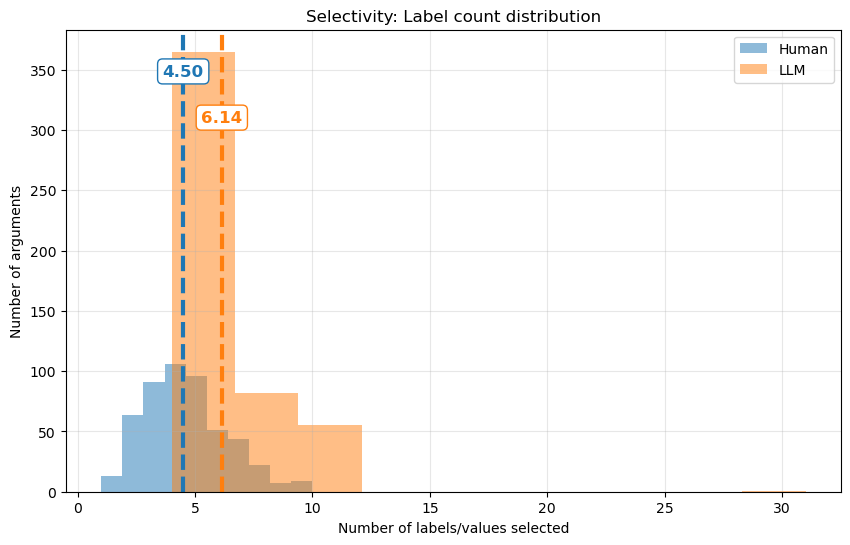

GT avg labels: 4.495029821073559
LLM avg labels: 6.809145129224652
LLM arguments with > 10 labels: 8 (1.59%)


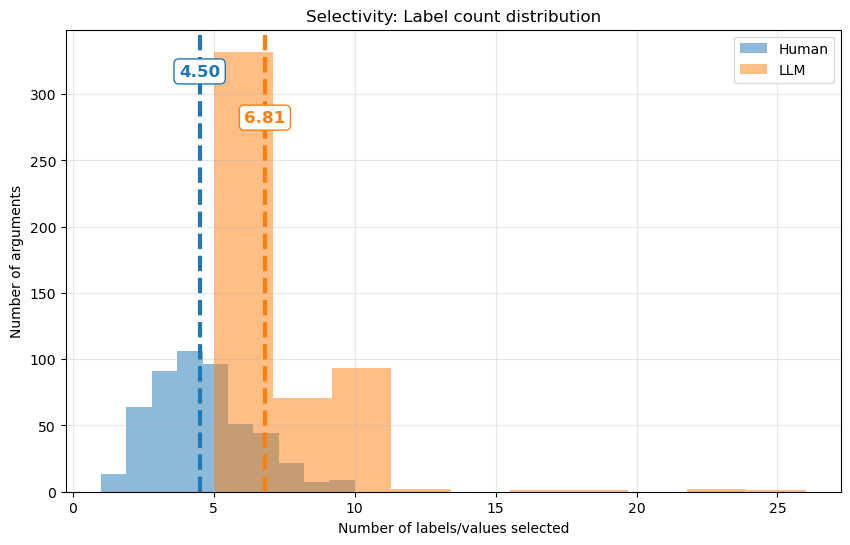

GT avg labels: 4.495029821073559
LLM avg labels: 6.1968190854870775
LLM arguments with > 10 labels: 7 (1.39%)


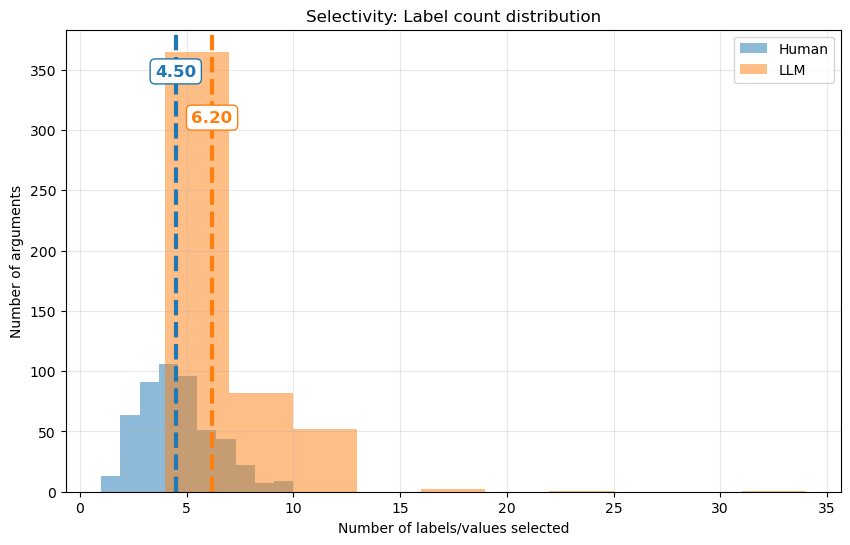

GT avg labels: 4.495029821073559
LLM avg labels: 6.31610337972167
LLM arguments with > 10 labels: 8 (1.59%)


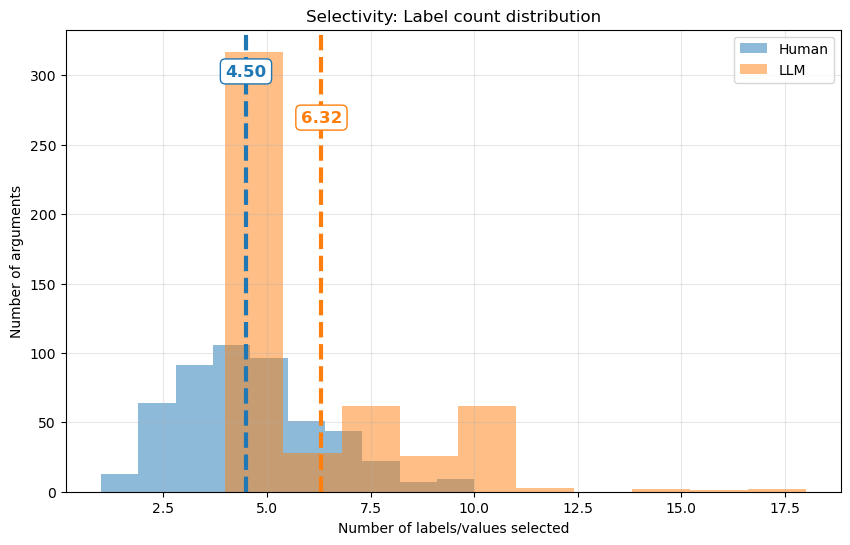

GT avg labels: 4.495029821073559
LLM avg labels: 5.954274353876739
LLM arguments with > 10 labels: 4 (0.80%)


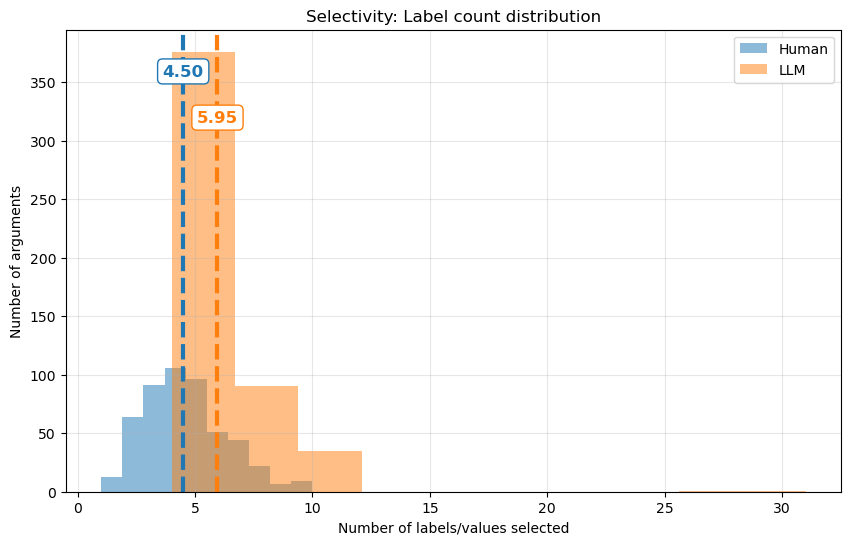

GT avg labels: 4.495029821073559
LLM avg labels: 5.709741550695825
LLM arguments with > 10 labels: 0 (0.00%)


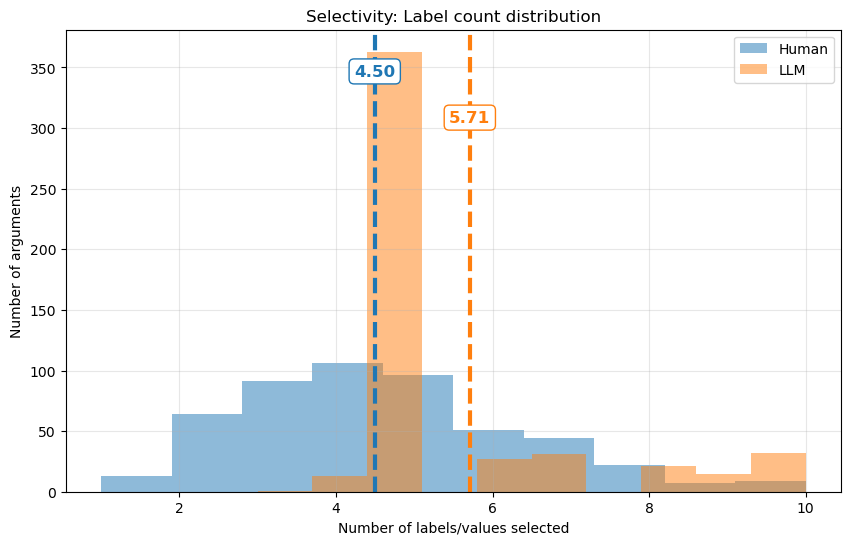

GT avg labels: 4.495029821073559
LLM avg labels: 16.230616302186878
LLM arguments with > 10 labels: 315 (62.62%)


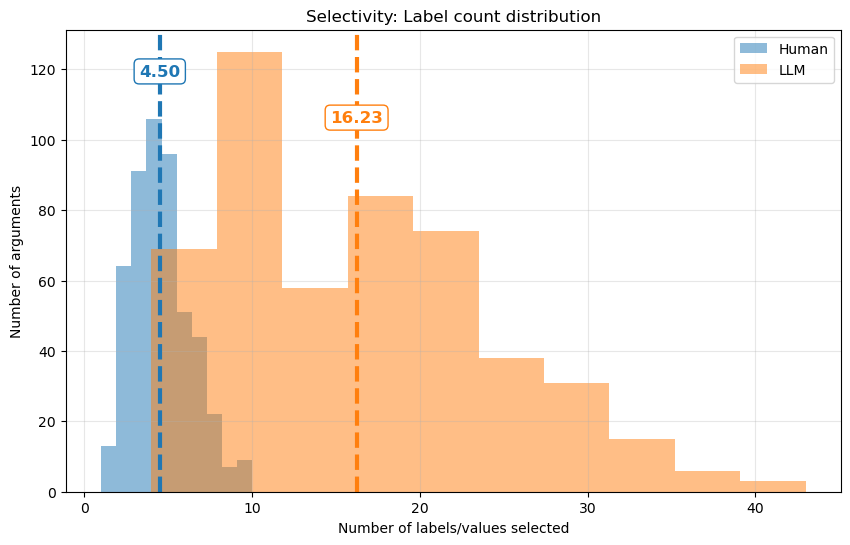

In [106]:
import os
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

for name in dataframes:
    y_pred = return_df_to_evaluation(name)
    true_counts = y_true.sum(axis=1)
    pred_counts = y_pred.sum(axis=1)

    mean_true = true_counts.mean()
    mean_pred = pred_counts.mean()

    print("GT avg labels:", mean_true)
    print("LLM avg labels:", mean_pred)
    num_over_10 = (pred_counts > 10).sum()
    percentage_over_10 = (pred_counts > 10).mean() * 100
    print(f"LLM arguments with > 10 labels: {num_over_10} ({percentage_over_10:.2f}%)")

    fig, ax = plt.subplots(figsize=(10, 6))

    color_human = "tab:blue"
    color_llm = "tab:orange"

    ax.hist(true_counts, bins=10, alpha=0.5, label="Human", color=color_human)
    ax.hist(pred_counts, bins=10, alpha=0.5, label="LLM", color=color_llm)

    ax.axvline(mean_true, linestyle='--', linewidth=3, color=color_human)
    ax.axvline(mean_pred, linestyle='--', linewidth=3, color=color_llm)

    y_max = ax.get_ylim()[1]

    ax.text(
        mean_true, y_max * 0.9, f"{mean_true:.2f}",
        color=color_human, fontsize=12, fontweight='bold',
        ha='center',
        bbox=dict(facecolor='white', edgecolor=color_human, boxstyle='round,pad=0.3')
    )

    ax.text(
        mean_pred, y_max * 0.8, f"{mean_pred:.2f}",
        color=color_llm, fontsize=12, fontweight='bold',
        ha='center',
        bbox=dict(facecolor='white', edgecolor=color_llm, boxstyle='round,pad=0.3')
    )

    ax.legend()
    ax.set_xlabel("Number of labels/values selected")
    ax.set_ylabel("Number of arguments")
    ax.set_title("Selectivity: Label count distribution")
    ax.grid(alpha=0.3)

    # Save as SVG
    fig.savefig(f"figures/freq_plot/{name}.svg",
                format="svg",
                bbox_inches="tight")

    plt.show()      # optional
    plt.close(fig)  # frees memory when looping over many figures

In [107]:
import json
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score,  f1_score, hamming_loss
import matplotlib.pyplot as plt


with open("values.json", "r", encoding="utf-8") as f:
    values_data = json.load(f)["values"]

value_map = pd.DataFrame(values_data)[
    ["name", "level2", "level3", "level4a", "level4b"]
]

def flatten_lists(df, col):
    df = df.copy()
    df[col] = df[col].apply(lambda x: x[0] if isinstance(x, list) else x)
    return df

value_map = flatten_lists(value_map, "level3")
value_map = flatten_lists(value_map, "level4a")
value_map = flatten_lists(value_map, "level4b")

groups = value_map.groupby("level2")["name"].apply(list)



In [108]:
def aggregate_to_level(df, value_map, level_col):
    df = df.copy()

    if "Argument ID" in df.columns:
        ids = df["Argument ID"]
        df = df.drop(columns=["Argument ID"])
    else:
        ids = None

    mapping = value_map.groupby(level_col)["name"].apply(list)

    new_df = pd.DataFrame()

    for level_name, cols in mapping.items():
        existing_cols = [c for c in cols if c in df.columns]

        if len(existing_cols) == 0:
            continue

        new_df[level_name] = df[existing_cols].max(axis=1)

    if ids is not None:
        new_df.insert(0, "Argument ID", ids)

    return new_df

levels = ["level2", "level3", "level4a", "level4b"]

def generate_all_levels(df, value_map):
    level_dfs = {}
    for lvl in levels:
        level_dfs[lvl] = aggregate_to_level(df, value_map, lvl)
    return level_dfs

In [109]:
pred_levels = generate_all_levels(y_pred.reset_index(), value_map)
gt_levels = generate_all_levels(y_true.reset_index(), value_map)

# for lvl in pred_levels:
#     pred_levels[lvl] = pred_levels[lvl].set_index("Argument ID")
#     gt_levels[lvl] = gt_levels[lvl].set_index("Argument ID")

In [110]:
pred_levels['level2']

,Argument ID,Achievement,Benevolence: caring,Benevolence: dependability,Conformity: interpersonal,Conformity: rules,Face,Hedonism,Humility,Power: dominance,...,Security: personal,Security: societal,Self-direction: action,Self-direction: thought,Stimulation,Tradition,Universalism: concern,Universalism: nature,Universalism: objectivity,Universalism: tolerance
0,A05039,1,1,1,0,0,1,0,0,0,...,1,1,0,0,0,0,0,0,0,0
1,A05040,1,1,1,0,1,1,0,1,0,...,1,1,0,0,0,1,1,1,1,1
2,A05041,1,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,1,0
3,A05042,0,1,1,0,0,0,0,0,0,...,0,0,1,1,0,1,1,0,0,0
4,A05044,0,0,1,0,1,0,0,0,1,...,0,1,0,0,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
498,A25476,1,1,1,0,0,0,0,0,0,...,0,0,1,1,1,0,0,0,1,0
499,A25480,1,1,1,0,0,0,0,0,1,...,0,1,1,1,1,0,1,0,1,1
500,A25486,1,1,1,0,0,0,1,0,0,...,1,1,1,0,1,0,1,0,0,0
501,A25493,1,1,1,1,1,1,1,1,1,...,1,1,0,0,0,1,1,0,0,1


In [111]:
def plot_value_distribution(y_true, y_pred, title, name, level, top_k=5):

    value_freq_true = y_true.mean(axis=0)
    value_freq_pred = y_pred.mean(axis=0)

    x = value_freq_true.values
    y = value_freq_pred.values
    labels = value_freq_true.index

    sizes = (x + y) * 3000
    bias = y - x

    fig, ax = plt.subplots(figsize=(13, 9))

    scatter = ax.scatter(
        x,
        y,
        s=sizes,
        c=bias,
        cmap="coolwarm",
        alpha=0.7,
        edgecolors="black",
        linewidth=0.5,
    )

    for i in range(len(x)):
        ax.text(x[i], y[i], str(i), fontsize=9, ha="center", va="center")

    idx_top = np.argsort(bias)[-top_k:]
    idx_bottom = np.argsort(bias)[:top_k]
    highlight_idx = set(np.concatenate([idx_top, idx_bottom]))

    for i in highlight_idx:
        ax.text(
            x[i],
            y[i],
            str(i),
            fontsize=11,
            fontweight="bold",
            ha="center",
            va="center",
        )

    max_val = max(max(x), max(y))
    ax.plot([0, max_val], [0, max_val], linestyle="--", color="gray")

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label("LLM - Human bias")

    ax.set_xlabel("Human frequency")
    ax.set_ylabel("LLM frequency")
    ax.set_title(title)
    ax.grid(True)

    y_pos = 0.95
    line_height = 0.018

    for i, label in enumerate(labels):
        style = {"fontsize": 10}

        if i in highlight_idx:
            style["fontweight"] = "bold"

        fig.text(
            0.86,
            y_pos - i * line_height,
            f"{i}: {label}",
            ha="left",
            va="top",
            **style,
        )

    plt.tight_layout(rect=[0, 0, 0.82, 1])

    # Save as SVG
    fig.savefig(
        f"figures/bubble_plot/level_{level}_{name}.svg",
        format="svg",
        bbox_inches="tight",
    )

    plt.show()      # optional
    plt.close(fig)  # recommended inside a loop

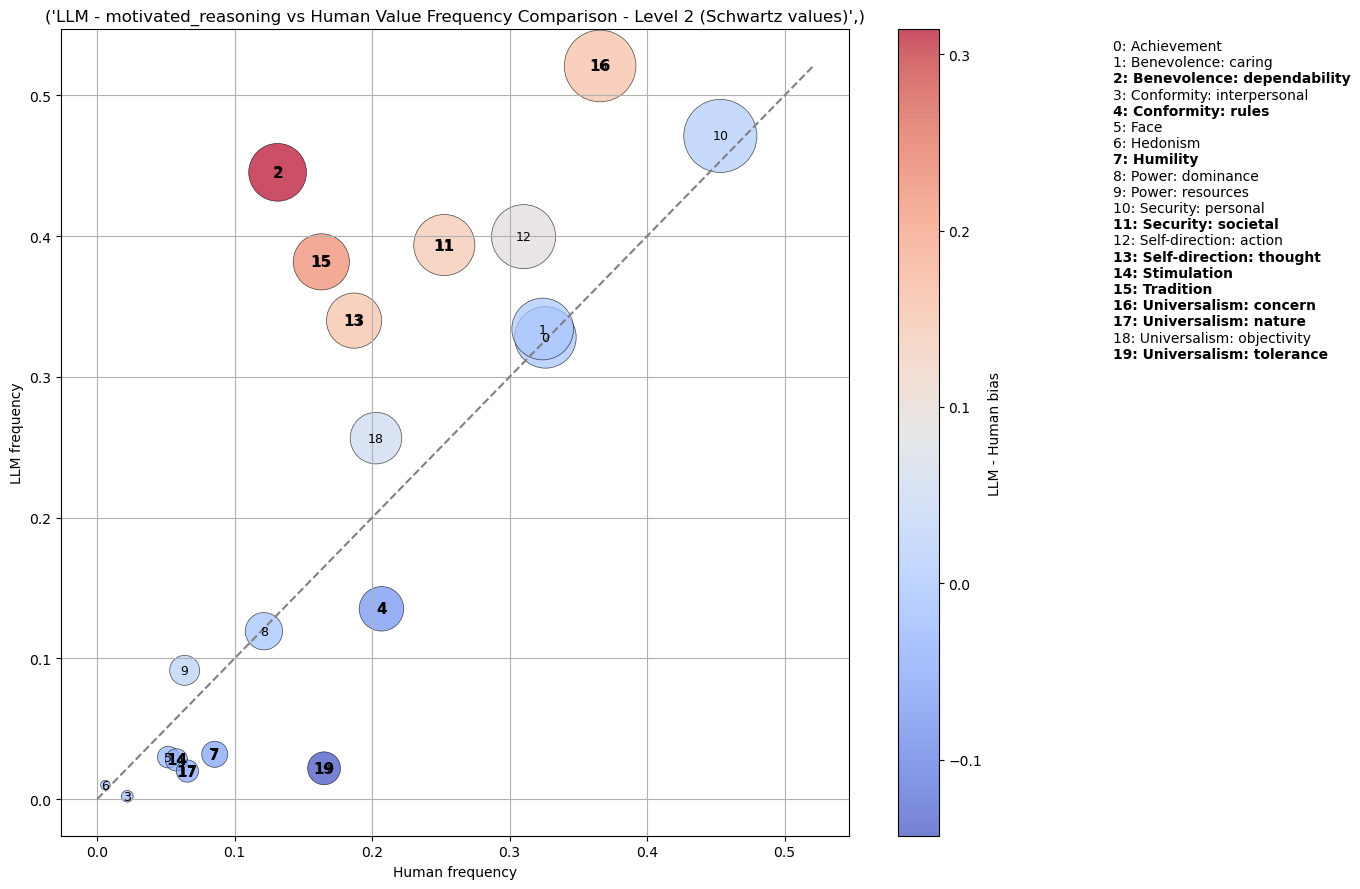

ValueError: operands could not be broadcast together with shapes (0,) (20,) 

In [ ]:
for name in dataframes:
    title=f"LLM - {name} vs Human Value Frequency Comparison - Level 1 (54 values)"
    level="1"
    y_true = ground_truth.set_index("Argument ID")

    y_pred = return_df_to_evaluation(name)
    common = y_true.index.intersection(y_pred.index)
    y_true,y_pred = y_true.loc[common], y_pred.loc[common]    # LEVEL 1 (original)
    plot_value_distribution(
        y_true,
        y_pred,
        title,
        name,
        level
    )

    
    title2=f"LLM - {name} vs Human Value Frequency Comparison - Level 2 (Schwartz values)",
    level2="2"
    pred_levels = generate_all_levels(y_pred.reset_index(), value_map)
    gt_levels = generate_all_levels(y_true.reset_index(), value_map)

    for lvl in pred_levels:
        pred_levels[lvl] = pred_levels[lvl].set_index("Argument ID")
        gt_levels[lvl] = gt_levels[lvl].set_index("Argument ID")

    y_pred = pred_levels['level2']
    y_true = gt_levels['level2']
    

    plot_value_distribution(
        y_true,
        y_pred,
        title2,
        name,
        level2
    )


In [ ]:
for lvl in ["level2", "level3", "level4a", "level4b"]:
    print(f"--- {lvl} ---")

    f1 = f1_score(
        gt_levels[lvl],
        pred_levels[lvl],
        average="macro",
        zero_division=0
    )
    print("Macro F1-Score:", f1)

    f1 = f1_score(
        gt_levels[lvl],
        pred_levels[lvl],
        average="micro",
        zero_division=0
    )
    print("Micro F1-Score:", f1)

    macro_precision = precision_score(gt_levels[lvl], pred_levels[lvl], average="macro", zero_division=0)
    macro_recall = recall_score(gt_levels[lvl], pred_levels[lvl], average="macro", zero_division=0)


    print("Kappa:", kappa_global(gt_levels[lvl], pred_levels[lvl]))

    from sklearn.metrics import jaccard_score

    jaccard_per_arg = []

    for i in range(len(gt_levels[lvl])):
        j = jaccard_score(gt_levels[lvl].iloc[i], pred_levels[lvl].iloc[i])
        jaccard_per_arg.append(j)

    print("Mean Jaccard:", np.mean(jaccard_per_arg))

    
    exact_match = np.mean([
        np.array_equal(gt_levels[lvl].iloc[i].values, pred_levels[lvl].iloc[i].values)
        for i in range(len(gt_levels[lvl]))
    ])

    print("Exact match:", exact_match)


--- level2 ---


NameError: name 'f1_score' is not defined